<a href="https://colab.research.google.com/github/CosmicAtomic/Aegis/blob/main/Copy_of_CSC323_Group12_Malaria_Prediction_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hybrid Machine Learning - LLM Framework for Predicting and Explaining Climate-Related Malaria Health Risks

**Course & Group:** GROUP 12 - CSC 323 PROJECT
**Geographical scope:** Nigeria, subnational (Lagos in focus)
**Unit of analysis:** admin unit x year  |  **Time range:** 2000-2022

---

`MAP incidence + ERA5 climate -> Feature engineering -> Random Forest -> SHAP -> LLM -> Natural-language explanation`

### Limitations

Initially we considered a **weekly** risk label for Lagos as a single point. That had two fatal problems for the project:

1. **No real weekly malaria series exists openly for Lagos.** Monthly LGA-level
   case data lives in the national DHIS2/NHMIS system and is only released on
   request from the State Primary Health Care Board.
2. **We are not allowed to synthesize data** The project has a restriction on synthesized data

hence, we updated the **unit of analysis** from *week* to *LGA-year*. This buys a real, externally-sourced target and genuine spatial variation, at the cost of temporal resolution.
Hence, we have move away from google earth engine entirely.

| Source | Role | Access |
|---|---|---|
| Malaria Atlas Project, **Subnational** unit data | **Target** - annual *P. falciparum* incidence per unit | Manual CSV export |
| geoBoundaries NGA ADM1/ADM2 | LGA polygons -> centroids + parent state | Open API |
| Open-Meteo ERA5 archive | Daily temperature, rainfall, humidity per centroid | Open API, no key |

Read section 9 (Detailed Limitations)

## 0 - Environment setup

In [ ]:
!pip install -q shap==0.46.0 scikit-learn pandas numpy matplotlib seaborn requests

import warnings, json, os, time, textwrap
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score,
                             f1_score, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
print("Setup complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Setup complete.


### Optional: Install and Start Ollama
Run this cell if you want to use a real local LLM instead of the template fallback. This takes ~3 minutes to download the model.

In [ ]:
# 1. Install dependencies (zstd) and Ollama
!sudo apt-get update && sudo apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh

# 2. Start the Ollama server in the background
import subprocess
import time
import os

# Ensure the ollama binary is in the path
os.environ['PATH'] += ':/usr/local/bin'

subprocess.Popen(['ollama', 'serve'])
time.sleep(10) # Give it 10 seconds to initialize

# 3. Pull the model (Llama 3.1)
!ollama pull llama3.1

print("\nOllama is now running and Llama 3.1 is ready!")

Get:1 https://cli.github.com/packages stable InRelease [4,685 B]
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,315 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,238 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,634 kB]
Get:14 h

## 1 - Global configuration

**Why more than Lagos?** Lagos State is about 3,600 km2 - smaller than a handful
of ERA5 grid cells. A Lagos-only panel has almost no climate gradient for the
model to learn from, so the Random Forest would be fitting noise. Including the
neighbouring South-West states gives a real rainfall and temperature gradient
while keeping Lagos as the focus of the SHAP and LLM narrative.

Set `states` to `["Lagos"]` if your brief strictly forbids this, but expect
weaker and less interpretable results, and say so in your report.

In [ ]:
CONFIG = {
    "states": ["Lagos", "Ogun", "Oyo", "Osun", "Ondo", "Ekiti"],
    "focus_state": "Lagos",
    "year_min": 2000,
    "year_max": 2022,
    "metric": "Incidence Rate",
    "random_state": 42,
    "therm": {"t_min": 16, "opt_lo": 22, "opt_hi": 32, "t_max": 40},
    "rf": {"n_estimators": 400, "max_depth": 8, "min_samples_leaf": 3,
           "class_weight": "balanced", "n_jobs": -1},
    "n_splits": 5,
    "risk_labels": ["Low", "Moderate", "High"],
    "cache_dir": "cache",
}
RS = CONFIG["random_state"]
np.random.seed(RS)

GEOBOUNDARIES_API  = "https://www.geoboundaries.org/api/current/gbOpen/NGA/{level}/"
OPEN_METEO_ARCHIVE = "https://archive-api.open-meteo.com/v1/archive"

print("States:", ", ".join(CONFIG["states"]))
print("Years :", CONFIG["year_min"], "-", CONFIG["year_max"])

States: Lagos, Ogun, Oyo, Osun, Ondo, Ekiti
Years : 2000 - 2022


## 2 - Data acquisition

### 2a - Get the Malaria Atlas Project target file  (MANUAL STEP - do this first)

Your v1 file was exported with the geographic level set to **National**, which
is why it had 5 rows. On https://data.malariaatlas.org:

1. Open the **Trends** view.
2. Find the geographic-level selector - it offers **National / Subnational /
   Pixel**. Change it from **National** to **Subnational**. *This one control is
   the whole fix.*
3. Region: **Nigeria**. Metric: **Incidence Rate**.
4. Filter the years, then click download.

**Two settings to get right on that same screen:**

**1. Region = all of Nigeria, NOT a single state.** If you filter to Lagos you
get one unit x 25 years = 25 rows. That is a single short time series, not a
panel - no spatial variation to learn from, and a Random Forest will overfit it
badly. Select Nigeria as a whole and you get 37 units x ~25 years (~900 rows).
Lagos still drives the SHAP and LLM narrative through `CONFIG["focus_state"]`.

**2. Metric = a RATE, not a count.** MAP offers raw counts ("Clinical Cases",
"Deaths") alongside rates ("Incidence Rate", "Mortality Rate"). Counts scale
with population, and Nigerian populations grew steeply over this period - Lagos
clinical cases fell 21% from 2000 to 2024, but once you divide by a population
that roughly tripled, the *rate* fell by around 70%. A model trained on counts is
substantially modelling demography rather than climate. Choose **Incidence
Rate**. (The loader auto-selects a rate metric if it finds one, and warns you if
your file only contains counts.)

**Check that your focus state is actually in the export.** MAP's multi-select
does not always return every state you ticked - a 36-states-plus-FCT selection
can come back with 35. `load_map_units()` prints a loud warning if
`CONFIG["focus_state"]` is missing. If it is, do a second small export covering
just the missing states and pass both files as a list:

```python
MAP_CSV = ["Subnational Unitdata 1.csv", "Lagos_topup.csv"]
```

**Which admin level will you get?** MAP publishes admin1 (states) for some
countries and admin2 (LGAs) for others. You do not need to know in advance -
`load_map_units()` reads the `Admin Level` column, prints what it found, and the
pipeline configures itself accordingly. Nigeria appears to resolve to **admin1**,
which means 37 states and a strong Sahel-to-coast climate gradient.

If the download gives you `Admin Level = admin0` again, the level selector did
not take - the loader will stop with an explicit error rather than silently
modelling 5 rows.

In [ ]:
# One file, or a LIST of files to concatenate. Use the list form if your main
# export is missing a state and you did a small top-up export to cover it:
#     MAP_CSV = ["Subnational Unitdata 1.csv", "Lagos_Osun_topup.csv"]
MAP_CSV = "Subnational Unit-data_latest.csv"

from google.colab import files as _colab_files
_need = [MAP_CSV] if isinstance(MAP_CSV, str) else list(MAP_CSV)
if any(not os.path.exists(p) for p in _need):
    print("Upload your MAP export(s) now:")
    up = _colab_files.upload()
    MAP_CSV = list(up.keys()) if len(up) > 1 else list(up.keys())[0]
    print("Using:", MAP_CSV)

Upload your MAP export(s) now:


Saving Subnational Unit-data.csv to Subnational Unit-data.csv
Using: Subnational Unit-data.csv


### 2b - Pipeline functions (loaders, geocoding, climate, features, target)

In [ ]:
# --------------------------------------------------------------------------
# 1. Malaria Atlas Project admin2 unit data  (the TARGET)
# --------------------------------------------------------------------------

def load_map_units(csv_path, config=CONFIG):
    """Load one MAP export, or several concatenated (pass a list of paths)."""
    if isinstance(csv_path, (list, tuple)):
        parts = [_load_one_map_csv(p, config) for p in csv_path]
        out = pd.concat(parts, ignore_index=True)
        out = out.drop_duplicates(subset=["lga", "year"]).reset_index(drop=True)
        out.attrs["admin_level"] = parts[0].attrs.get("admin_level", "admin1")
        print(f"  combined {len(csv_path)} files -> {out['lga'].nunique()} units, "
              f"{len(out)} rows")
        _check_units(out, config)
        return out
    out = _load_one_map_csv(csv_path, config)
    _check_units(out, config)
    return out


def _check_units(out, config=CONFIG):
    n_units = out["lga"].nunique()
    if n_units < 5:
        raise ValueError(
            f"Only {n_units} spatial unit(s) in this export "
            f"({sorted(out['lga'].unique())}) -> {len(out)} rows total. That is a "
            f"single short time series, not a panel.\n\n"
            f"Fix: on data.malariaatlas.org keep the level on 'Subnational' but "
            f"select ALL of Nigeria rather than one state."
        )
    focus = config.get("focus_state")
    if focus and _normalise_name(focus) not in {_normalise_name(u)
                                                for u in out["lga"].unique()}:
        print(f"\n  *** WARNING: focus state {focus!r} is NOT in this export. ***")
        print(f"      The model will still train, but the SHAP waterfall and the")
        print(f"      LLM briefings cannot be about {focus}, which is the point of")
        print(f"      the project. Re-export including {focus}, or pass a list of")
        print(f"      CSVs to load_map_units([...]) to merge a top-up export.\n")


def _load_one_map_csv(csv_path, config=CONFIG):
    """
    Read a Malaria Atlas Project 'unit data' CSV exported at admin1 or admin2.

    Export it yourself from https://data.malariaatlas.org :
        Country = Nigeria -> Admin level = Admin 2 -> Metric = Incidence Rate
        -> Download CSV.

    The export uses the same schema as the admin0 file you already have
    (ISO3, Name, Admin Level, Metric, Units, Year, Value), so this loader
    is deliberately tolerant about extra ID columns.
    """
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]

    def _find(*candidates):
        for cand in candidates:
            for col in df.columns:
                if col.lower().replace("_", " ").strip() == cand:
                    return col
        return None

    col_name = _find("name", "admin2", "unit name", "shapename")
    col_year = _find("year")
    col_val = _find("value")
    col_metric = _find("metric")
    col_level = _find("admin level", "adminlevel")

    missing = [n for n, c in
               [("Name", col_name), ("Year", col_year), ("Value", col_val)]
               if c is None]
    if missing:
        raise ValueError(
            f"Could not find column(s) {missing} in {csv_path}. "
            f"Columns present: {list(df.columns)}"
        )

    if col_metric is not None:
        available = sorted(df[col_metric].astype(str).str.strip().unique())
        chosen = config["metric"] if config["metric"] in available else None

        if chosen is None:
            # Prefer a POPULATION-ADJUSTED metric. A raw count ("Clinical
            # Cases", "Deaths") is confounded by population growth: Lagos
            # roughly tripled in population 2000-2024, so a flat case count
            # actually means a collapsing rate. Modelling counts from climate
            # would largely be modelling demography.
            for pref in ("Incidence Rate", "Infection Prevalence",
                         "Mortality Rate", "Prevalence Rate"):
                if pref in available:
                    chosen = pref
                    break
            if chosen is None:
                rate_like = [m for m in available
                             if any(k in m.lower()
                                    for k in ("rate", "prevalence", "per "))]
                chosen = rate_like[0] if rate_like else None

            if chosen is None:
                raise ValueError(
                    f"No rate-style metric found in {csv_path}. Available: "
                    f"{available}. Metrics like 'Clinical Cases' and 'Deaths' "
                    f"are raw COUNTS - re-export choosing a rate metric "
                    f"(e.g. 'Incidence Rate'), because counts track population "
                    f"size more than they track malaria risk."
                )
            print(f"  metric: {chosen!r} (requested {config['metric']!r} "
                  f"not present; available: {available})")
        else:
            print(f"  metric: {chosen!r}")

        if any(k in chosen.lower() for k in ("case", "death", "count")) \
           and "rate" not in chosen.lower():
            print("  WARNING: this metric looks like a raw COUNT, not a rate. "
                  "Counts scale with population - prefer 'Incidence Rate'.")

        df = df[df[col_metric].astype(str).str.strip() == chosen]

    detected = None
    if col_level is not None:
        levels = df[col_level].astype(str).str.lower().str.strip().unique()
        if len(levels) == 1 and levels[0] == "admin0":
            raise ValueError(
                "This export is admin0 (national) only - it has one row per "
                "year for the whole of Nigeria and cannot support a "
                "subnational model. On data.malariaatlas.org, switch the "
                "geographic level selector from 'National' to 'Subnational' "
                "and download again."
            )
        for lvl in ("admin2", "admin1"):
            if lvl in levels:
                detected = lvl
                break

    out = (df[[col_name, col_year, col_val]]
           .rename(columns={col_name: "lga", col_year: "year", col_val: "incidence"}))
    out["lga"] = out["lga"].astype(str).str.strip()
    out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
    out["incidence"] = pd.to_numeric(out["incidence"], errors="coerce")
    out = out.dropna(subset=["year", "incidence"])
    out["year"] = out["year"].astype(int)

    out = out[(out["year"] >= config["year_min"]) & (out["year"] <= config["year_max"])]
    out = out.drop_duplicates(subset=["lga", "year"]).reset_index(drop=True)

    # Fall back to a count-based guess when the file has no Admin Level column.
    if detected is None:
        detected = "admin2" if out["lga"].nunique() > 60 else "admin1"
    out.attrs["admin_level"] = detected
    n_units = out["lga"].nunique()
    print(f"  detected admin level: {detected} ({n_units} distinct units, "
          f"{len(out)} rows)")

    return out


# --------------------------------------------------------------------------
# 2. geoBoundaries - LGA centroids and their parent state
# --------------------------------------------------------------------------

def _cache_path(name, config=CONFIG):
    os.makedirs(config["cache_dir"], exist_ok=True)
    return os.path.join(config["cache_dir"], name)


def _download_geojson(level, config=CONFIG):
    """Fetch a geoBoundaries GeoJSON for Nigeria, caching to disk."""
    cache = _cache_path(f"NGA_{level}.geojson", config)
    if os.path.exists(cache):
        with open(cache) as f:
            return json.load(f)

    meta = requests.get(GEOBOUNDARIES_API.format(level=level), timeout=60)
    meta.raise_for_status()
    url = meta.json()["gjDownloadURL"]

    gj = requests.get(url, timeout=180)
    gj.raise_for_status()
    data = gj.json()
    with open(cache, "w") as f:
        json.dump(data, f)
    return data


def _polygon_rings(geometry):
    """Yield exterior rings from a (Multi)Polygon geometry."""
    if geometry["type"] == "Polygon":
        yield geometry["coordinates"][0]
    elif geometry["type"] == "MultiPolygon":
        for poly in geometry["coordinates"]:
            yield poly[0]


def _ring_centroid_and_area(ring):
    """Shoelace centroid + signed area of a linear ring of (lon, lat)."""
    pts = np.asarray(ring, dtype=float)
    x, y = pts[:, 0], pts[:, 1]
    x1, y1 = np.roll(x, -1), np.roll(y, -1)
    cross = x * y1 - x1 * y
    area = cross.sum() / 2.0
    if abs(area) < 1e-12:
        return float(x.mean()), float(y.mean()), 0.0
    cx = ((x + x1) * cross).sum() / (6.0 * area)
    cy = ((y + y1) * cross).sum() / (6.0 * area)
    return float(cx), float(cy), float(area)


def _feature_centroid(feature):
    """Area-weighted centroid across all parts of a (Multi)Polygon."""
    tot_a = 0.0
    sx = sy = 0.0
    fallback = []
    for ring in _polygon_rings(feature["geometry"]):
        cx, cy, a = _ring_centroid_and_area(ring)
        fallback.append((cx, cy))
        sx += cx * abs(a)
        sy += cy * abs(a)
        tot_a += abs(a)
    if tot_a == 0:
        arr = np.asarray(fallback, dtype=float)
        return float(arr[:, 0].mean()), float(arr[:, 1].mean())
    return sx / tot_a, sy / tot_a


def _point_in_ring(lon, lat, ring):
    """Ray-casting point-in-polygon test."""
    pts = np.asarray(ring, dtype=float)
    x, y = pts[:, 0], pts[:, 1]
    x1, y1 = np.roll(x, -1), np.roll(y, -1)
    crosses = ((y > lat) != (y1 > lat))
    with np.errstate(divide="ignore", invalid="ignore"):
        xint = x + (lat - y) / np.where(y1 - y == 0, np.nan, y1 - y) * (x1 - x)
    hits = crosses & (lon < np.nan_to_num(xint, nan=-np.inf))
    return bool(hits.sum() % 2 == 1)


def _point_in_feature(lon, lat, feature):
    return any(_point_in_ring(lon, lat, ring)
               for ring in _polygon_rings(feature["geometry"]))


def build_unit_centroids(admin_level="admin2", config=CONFIG):
    """
    Return DataFrame [lga, state, lat, lon] of unit centroids.

    admin_level="admin2" -> units are LGAs, each tagged with its parent state.
    admin_level="admin1" -> units are states; `lga` and `state` are the same.

    config["states"] filters the result. Set it to None (or an empty list) to
    keep every unit in Nigeria - which is what you want at admin1, where 37
    states across the whole country give a far stronger climate gradient than
    six South-West states.
    """
    adm1 = _download_geojson("ADM1", config)
    wanted = config.get("states") or None
    wanted = {s.lower().strip() for s in wanted} if wanted else None

    adm1_feats = [f for f in adm1["features"]
                  if wanted is None
                  or str(f["properties"].get("shapeName", "")).lower().strip() in wanted]
    if not adm1_feats:
        available = sorted(str(f["properties"].get("shapeName"))
                           for f in adm1["features"])
        raise ValueError(f"No ADM1 match for {config['states']}. Available: {available}")

    if admin_level == "admin1":
        rows = []
        for feat in adm1_feats:
            name = str(feat["properties"]["shapeName"]).strip()
            lon, lat = _feature_centroid(feat)
            rows.append({"lga": name, "state": name,
                         "lat": round(lat, 4), "lon": round(lon, 4)})
        out = pd.DataFrame(rows)
        return out.sort_values("lga").reset_index(drop=True)

    adm2 = _download_geojson("ADM2", config)
    rows = []
    for feat in adm2["features"]:
        name = str(feat["properties"].get("shapeName", "")).strip()
        if not name:
            continue
        lon, lat = _feature_centroid(feat)
        for state_feat in adm1_feats:
            if _point_in_feature(lon, lat, state_feat):
                rows.append({
                    "lga": name,
                    "state": str(state_feat["properties"]["shapeName"]).strip(),
                    "lat": round(lat, 4),
                    "lon": round(lon, 4),
                })
                break

    out = pd.DataFrame(rows).drop_duplicates(subset=["lga", "state"])
    return out.sort_values(["state", "lga"]).reset_index(drop=True)


# Backwards-compatible alias
def build_lga_centroids(config=CONFIG):
    return build_unit_centroids("admin2", config)


# --------------------------------------------------------------------------
# 3. Open-Meteo ERA5 archive - daily climate per LGA centroid
# --------------------------------------------------------------------------

DAILY_VARS = [
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "relative_humidity_2m_mean",
]


def fetch_daily_climate(lat, lon, year_min, year_max, config=CONFIG,
                        max_retries=4, pause=0.4):
    """Daily ERA5 reanalysis for one point. Cached to disk by coordinate."""
    cache = _cache_path(f"om_{lat:.4f}_{lon:.4f}_{year_min}_{year_max}.csv", config)
    if os.path.exists(cache):
        return pd.read_csv(cache, parse_dates=["date"])

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": f"{year_min}-01-01",
        "end_date": f"{year_max}-12-31",
        "daily": ",".join(DAILY_VARS),
        "timezone": "UTC",
    }

    last_err = None
    for attempt in range(max_retries):
        try:
            r = requests.get(OPEN_METEO_ARCHIVE, params=params, timeout=120)
            if r.status_code == 429:            # rate limited - back off
                time.sleep(5 * (attempt + 1))
                continue
            r.raise_for_status()
            daily = r.json()["daily"]
            df = pd.DataFrame(daily).rename(columns={"time": "date"})
            df["date"] = pd.to_datetime(df["date"])
            df.to_csv(cache, index=False)
            time.sleep(pause)
            return df
        except Exception as e:                  # noqa: BLE001
            last_err = e
            time.sleep(2 * (attempt + 1))

    raise RuntimeError(f"Open-Meteo failed for ({lat}, {lon}): {last_err}")


def fetch_all_climate(centroids, config=CONFIG, verbose=True):
    """Loop over LGA centroids, returning one tidy daily frame."""
    frames = []
    n = len(centroids)
    for i, row in centroids.reset_index(drop=True).iterrows():
        if verbose and (i % 10 == 0 or i == n - 1):
            print(f"  [{i + 1:>3}/{n}] {row['state']:<8} {row['lga']}")
        df = fetch_daily_climate(row["lat"], row["lon"],
                                 config["year_min"], config["year_max"], config)
        df = df.copy()
        df["lga"] = row["lga"]
        df["state"] = row["state"]
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


# --------------------------------------------------------------------------
# 4. Feature engineering  (annual, but built from DAILY data)
# --------------------------------------------------------------------------

def thermal_suitability(T, therm=None):
    """Trapezoidal suitability curve for P. falciparum (0 unsuitable, 1 optimal)."""
    therm = therm or CONFIG["therm"]
    T = np.asarray(T, dtype=float)
    tmin, olo, ohi, tmax = therm["t_min"], therm["opt_lo"], therm["opt_hi"], therm["t_max"]
    s = np.zeros_like(T)
    up = (T >= tmin) & (T < olo)
    s[up] = (T[up] - tmin) / (olo - tmin)
    s[(T >= olo) & (T <= ohi)] = 1.0
    dn = (T > ohi) & (T <= tmax)
    s[dn] = (tmax - T[dn]) / (tmax - ohi)
    return np.clip(s, 0, 1)


WET_MONTHS = (4, 5, 6, 7, 8, 9, 10)   # Apr-Oct: the South-West Nigeria wet season


def engineer_features(daily, config=CONFIG):
    """
    Collapse daily climate into one row per (LGA, year).

    The weekly lag features from the original notebook cannot survive an
    annual target, so the transmission-biology story is carried instead by
    WITHIN-year structure (wet-season totals, suitable-day counts, seasonal
    range) plus a genuine one-year lag.
    """
    d = daily.copy()
    d["year"] = d["date"].dt.year
    d["month"] = d["date"].dt.month
    d["suit"] = thermal_suitability(d["temperature_2m_mean"], config["therm"])
    d["is_wet"] = d["month"].isin(WET_MONTHS)
    d["rain_day"] = d["precipitation_sum"] > 1.0
    d["suit_day"] = d["suit"] > 0.5

    g = d.groupby(["state", "lga", "year"])
    feat = g.agg(
        rain_total_mm=("precipitation_sum", "sum"),
        rain_days=("rain_day", "sum"),
        temp_mean_c=("temperature_2m_mean", "mean"),
        temp_max_mean_c=("temperature_2m_max", "mean"),
        temp_min_mean_c=("temperature_2m_min", "mean"),
        humidity_mean_pct=("relative_humidity_2m_mean", "mean"),
        thermal_suit_mean=("suit", "mean"),
        thermal_suit_days=("suit_day", "sum"),
    ).reset_index()

    wet = (d[d["is_wet"]].groupby(["state", "lga", "year"])["precipitation_sum"]
           .sum().rename("rain_wet_season_mm").reset_index())
    feat = feat.merge(wet, on=["state", "lga", "year"], how="left")

    monthly = (d.groupby(["state", "lga", "year", "month"])["precipitation_sum"]
               .sum().reset_index())
    peak = (monthly.groupby(["state", "lga", "year"])["precipitation_sum"]
            .max().rename("rain_peak_month_mm").reset_index())
    feat = feat.merge(peak, on=["state", "lga", "year"], how="left")

    mt = (d.groupby(["state", "lga", "year", "month"])["temperature_2m_mean"]
          .mean().reset_index())
    rng = (mt.groupby(["state", "lga", "year"])["temperature_2m_mean"]
           .agg(lambda s: s.max() - s.min()).rename("temp_seasonal_range_c").reset_index())
    feat = feat.merge(rng, on=["state", "lga", "year"], how="left")

    # Genuine temporal lag: last year's conditions, within each LGA.
    feat = feat.sort_values(["state", "lga", "year"]).reset_index(drop=True)
    for src, dst in [("rain_total_mm", "rain_lag1y_mm"),
                     ("temp_mean_c", "temp_lag1y_c"),
                     ("thermal_suit_mean", "thermal_suit_lag1y")]:
        feat[dst] = feat.groupby(["state", "lga"])[src].shift(1)

    return feat.dropna().reset_index(drop=True)


FEATURES = [
    "rain_total_mm", "rain_wet_season_mm", "rain_peak_month_mm", "rain_days",
    "temp_mean_c", "temp_max_mean_c", "temp_min_mean_c", "temp_seasonal_range_c",
    "humidity_mean_pct", "thermal_suit_mean", "thermal_suit_days",
    "rain_lag1y_mm", "temp_lag1y_c", "thermal_suit_lag1y",
]


# --------------------------------------------------------------------------
# 5. The target  (replaces the synthetic build_target)
# --------------------------------------------------------------------------

# MAP and geoBoundaries spell several Nigerian units differently. Without
# these aliases the centroid join silently drops the affected states.
NAME_ALIASES = {
    "abuja": "federal capital territory",
    "fct": "federal capital territory",
    "abuja federal capital territory": "federal capital territory",
    "nassarawa": "nasarawa",
    "akwa ibom": "akwa ibom",
    "cross river": "cross river",
}


def _normalise_name(s):
    """Loose match key for unit names across MAP and geoBoundaries spellings."""
    key = (str(s).lower()
           .replace("-", " ").replace("/", " ").replace("'", "")
           .replace("_", " ").replace(".", "")
           .replace("local government area", "").replace(" lga", "")
           .replace(" state", "")
           .strip())
    while "  " in key:
        key = key.replace("  ", " ")
    return NAME_ALIASES.get(key, key)


def build_target(features, map_units, config=CONFIG):
    """
    Merge REAL MAP incidence onto the climate features and bin into
    Low / Moderate / High by tertile.

    No synthetic latent variable, no injected coefficients: the class labels
    come from an external estimate the model has never seen.
    """
    f = features.copy()
    m = map_units.copy()
    f["_key"] = f["lga"].map(_normalise_name)
    m["_key"] = m["lga"].map(_normalise_name)

    merged = f.merge(m[["_key", "year", "incidence"]],
                     on=["_key", "year"], how="inner").drop(columns="_key")

    unmatched = sorted(set(f["_key"]) - set(m["_key"]))
    if unmatched:
        print(f"  note: {len(unmatched)} LGA name(s) did not match MAP, e.g. "
              f"{unmatched[:5]}")

    if merged.empty:
        raise ValueError(
            "Nothing merged. Check that the MAP export is admin2 and that its "
            "Name column holds LGA names."
        )

    q_lo, q_hi = merged["incidence"].quantile([1 / 3, 2 / 3])
    merged["risk_level"] = pd.cut(
        merged["incidence"],
        bins=[-np.inf, q_lo, q_hi, np.inf],
        labels=config["risk_labels"],
    )
    merged["date"] = pd.to_datetime(merged["year"].astype(str) + "-07-01")
    return merged.sort_values(["year", "state", "lga"]).reset_index(drop=True)

In [ ]:
POWER_API = "https://power.larc.nasa.gov/api/temporal/daily/point"
POWER_VARS = {
    "T2M":         "temperature_2m_mean",
    "T2M_MAX":     "temperature_2m_max",
    "T2M_MIN":     "temperature_2m_min",
    "PRECTOTCORR": "precipitation_sum",
    "RH2M":        "relative_humidity_2m_mean",
}

def fetch_daily_climate(lat, lon, year_min, year_max, config=CONFIG,
                        max_retries=4, pause=0.5, **kwargs):
    cache = _cache_path(f"power_{lat:.4f}_{lon:.4f}_{year_min}_{year_max}.csv", config)
    if os.path.exists(cache):
        return pd.read_csv(cache, parse_dates=["date"])

    params = {
        "parameters": ",".join(POWER_VARS), "community": "AG",
        "longitude": lon, "latitude": lat,
        "start": f"{year_min}0101", "end": f"{year_max}1231", "format": "JSON",
    }
    last_err = None
    for attempt in range(max_retries):
        try:
            r = requests.get(POWER_API, params=params, timeout=180)
            r.raise_for_status()
            payload = r.json()
            try:
                block = payload["properties"]["parameter"]
            except (KeyError, TypeError):
                raise RuntimeError(
                    f"Unexpected POWER response. Top-level keys: {list(payload)[:8]}. "
                    f"Body starts: {str(payload)[:300]}")

            df = pd.DataFrame({dst: pd.Series(block[src])
                               for src, dst in POWER_VARS.items()})
            df.index.name = "date"
            df = df.reset_index()
            df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")

            num = list(POWER_VARS.values())          # POWER uses -999 as fill
            df[num] = df[num].mask(df[num] <= -900)
            df[num] = df[num].interpolate(limit_direction="both")
            df.loc[df["precipitation_sum"] < 0, "precipitation_sum"] = 0.0

            df = df.sort_values("date").reset_index(drop=True)
            df.to_csv(cache, index=False)
            time.sleep(pause)
            return df
        except Exception as e:
            last_err = f"{type(e).__name__}: {e}"
            time.sleep(3 * (attempt + 1))
    raise RuntimeError(f"NASA POWER failed for ({lat}, {lon}): {last_err}")

print("fetcher switched to NASA POWER")

fetcher switched to NASA POWER


### 2c - Run the acquisition

The Open-Meteo loop makes one request per LGA and caches each response to
`cache/`, so re-running this cell is instant. Expect roughly 3-6 minutes on the
first run for ~137 units (faster at admin1, which has only 37).

In [ ]:
print("Loading MAP target ...")
map_units = load_map_units(MAP_CSV, CONFIG)
print(f"  {len(map_units):,} LGA-year incidence records, "
      f"{map_units['lga'].nunique()} distinct units, "
      f"{map_units['year'].min()}-{map_units['year'].max()}\n")

ADMIN_LEVEL = map_units.attrs.get("admin_level", "admin2")

if ADMIN_LEVEL == "admin1" and CONFIG["states"]:
    print("  admin1 data detected -> using ALL Nigerian states "
          "(clearing the South-West filter for a wider climate gradient)")
    CONFIG["states"] = None

print(f"\nResolving {ADMIN_LEVEL} centroids from geoBoundaries ...")
centroids = build_unit_centroids(ADMIN_LEVEL, CONFIG)
print(f"  {len(centroids)} units across {centroids['state'].nunique()} states")
if ADMIN_LEVEL == "admin2":
    print(centroids.groupby('state').size().to_string(), "\n")

print("Fetching ERA5 daily climate from Open-Meteo ...")
daily = fetch_all_climate(centroids, CONFIG)
print(f"  {len(daily):,} daily records\n")
daily.head()

Loading MAP target ...
  metric: 'Incidence Rate'
  detected admin level: admin1 (37 distinct units, 851 rows)
  851 LGA-year incidence records, 37 distinct units, 2000-2022

  admin1 data detected -> using ALL Nigerian states (clearing the South-West filter for a wider climate gradient)

Resolving admin1 centroids from geoBoundaries ...
  37 units across 37 states
Fetching ERA5 daily climate from Open-Meteo ...
  [  1/37] Abia     Abia
  [ 11/37] Delta    Delta
  [ 21/37] Katsina  Katsina
  [ 31/37] Oyo      Oyo
  [ 37/37] Zamfara  Zamfara
  310,837 daily records



,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,relative_humidity_2m_mean,lga,state
0,2000-01-01,25.85,30.17,22.18,0.17,85.84,Abia,Abia
1,2000-01-02,25.61,29.58,22.10,0.03,86.24,Abia,Abia
2,2000-01-03,25.44,28.85,21.97,0.03,86.27,Abia,Abia
3,2000-01-04,25.27,28.89,21.63,0.10,85.04,Abia,Abia
4,2000-01-05,24.75,29.36,20.83,0.00,69.91,Abia,Abia


### 2d - Sanity-check plots

Confirm the climatology looks like South-West Nigeria before modelling anything.

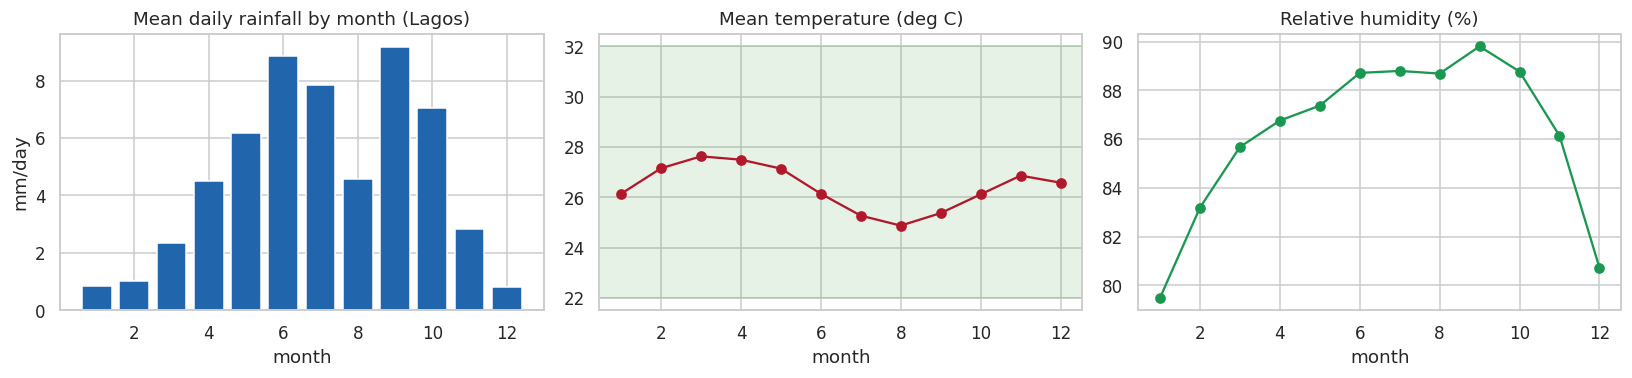

Expected: a April-October wet season with a brief August dip, temperatures sitting inside the 22-32 deg C band all year.


In [ ]:
_fs = CONFIG["focus_state"]
focus = daily[daily["state"] == _fs].copy()
if focus.empty:
    print(f"note: '{_fs}' not among the units; plotting all units instead")
    focus = daily.copy()
focus["month"] = focus["date"].dt.month
clim = focus.groupby("month").agg(
    rain=("precipitation_sum", "mean"),
    temp=("temperature_2m_mean", "mean"),
    hum=("relative_humidity_2m_mean", "mean")).reset_index()

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].bar(clim["month"], clim["rain"], color="#2166ac")
ax[0].set_title(f"Mean daily rainfall by month ({CONFIG['focus_state']})")
ax[0].set_xlabel("month"); ax[0].set_ylabel("mm/day")

ax[1].plot(clim["month"], clim["temp"], color="#b2182b", marker="o")
ax[1].axhspan(22, 32, color="green", alpha=.10)
ax[1].set_title("Mean temperature (deg C)"); ax[1].set_xlabel("month")

ax[2].plot(clim["month"], clim["hum"], color="#1a9850", marker="o")
ax[2].set_title("Relative humidity (%)"); ax[2].set_xlabel("month")
plt.tight_layout(); plt.show()

print("Expected: a April-October wet season with a brief August dip, "
      "temperatures sitting inside the 22-32 deg C band all year.")

## 3 - Feature engineering

The weekly lag features from v1 cannot survive an annual target, so the
transmission-biology story is carried instead by **within-year structure**
computed from daily data, plus a genuine one-year lag:

1. **Wet-season rainfall totals** (`rain_wet_season_mm`, `rain_peak_month_mm`,
   `rain_days`) - standing water from accumulated rain drives *Anopheles*
   breeding. Aggregated over Apr-Oct rather than the whole year so that a wet
   year and an evenly-damp year are distinguishable.
2. **Thermal suitability** (`thermal_suit_mean`, `thermal_suit_days`) - the same
   trapezoidal 22-32 deg C curve as v1, but applied to *daily* mean temperature
   and then averaged, so a year that swings above 32 deg C correctly scores
   lower than a year that sits in the band.
3. **Seasonality** (`temp_seasonal_range_c`) - the month-to-month temperature
   spread within the year.
4. **One-year lags** (`rain_lag1y_mm`, `temp_lag1y_c`, `thermal_suit_lag1y`) -
   computed *within each LGA*, so the model can express the idea that last
   year's conditions shape this year's transmission reservoir.

In [ ]:
feat_df = engineer_features(daily, CONFIG)
print("Engineered feature frame:", feat_df.shape)
print("Features:", len(FEATURES))
feat_df.head()

Engineered feature frame: (814, 17)
Features: 14


,state,lga,year,rain_total_mm,rain_days,temp_mean_c,temp_max_mean_c,temp_min_mean_c,humidity_mean_pct,thermal_suit_mean,thermal_suit_days,rain_wet_season_mm,rain_peak_month_mm,temp_seasonal_range_c,rain_lag1y_mm,temp_lag1y_c,thermal_suit_lag1y
0,Abia,Abia,2001,2109.51,236,24.993808,28.863315,21.817781,85.809699,0.993164,365,1875.34,386.69,3.540645,3542.25,24.982596,0.995496
1,Abia,Abia,2002,1862.15,243,25.212137,29.052630,22.019671,84.988356,0.993064,365,1709.72,467.68,3.747742,2109.51,24.993808,0.993164
2,Abia,Abia,2003,1764.36,245,25.518795,29.122521,22.593123,86.765890,0.998639,365,1474.16,307.78,2.253226,1862.15,25.212137,0.993064
3,Abia,Abia,2004,1561.18,229,25.500301,29.085874,22.615137,86.876694,1.000000,366,1403.80,286.40,2.076129,1764.36,25.518795,0.998639
4,Abia,Abia,2005,1481.78,220,25.660795,29.447836,22.667918,86.474164,0.991945,363,1315.07,458.29,3.802656,1561.18,25.500301,1.000000


### 3b - Constructing the malaria-risk target

**This is the cell that changed most.** There is no synthetic latent variable
and no injected coefficients any more.

`build_target()` merges the **real MAP annual incidence estimate** onto the
climate features by (LGA, year), then bins the incidence into
**Low / Moderate / High** by tertile. LGA names are matched with a normalising
key, because MAP and geoBoundaries disagree on hyphens, slashes and
capitalisation (`Ado-Odo/Ota` vs `ADO ODO OTA`).

Tertiles are used rather than v1's 40/75 split so the three classes are balanced
by construction - which means accuracy has a clean 33% baseline to beat.

In [ ]:
model_df = build_target(feat_df, map_units, CONFIG)

print("Modelling frame:", model_df.shape)
print(f"  {model_df['lga'].nunique()} LGAs x "
      f"{model_df['year'].nunique()} years\n")
print(model_df["risk_level"].value_counts().to_string(), "\n")

ORDER = {"Low": 0, "Moderate": 1, "High": 2}
ORDERED_LABELS = ["Low", "Moderate", "High"]

X      = model_df[FEATURES].copy()
y      = model_df["risk_level"].map(ORDER).astype(int).to_numpy()
groups = model_df["lga"].to_numpy()

print("X:", X.shape, "| class counts:", np.bincount(y))
print("Baseline accuracy (majority class): "
      f"{np.bincount(y).max() / len(y):.3f}")

Modelling frame: (814, 20)
  37 LGAs x 22 years

risk_level
Low         272
Moderate    271
High        271 

X: (814, 14) | class counts: [272 271 271]
Baseline accuracy (majority class): 0.334


## 4 - Random Forest with panel-aware cross-validation

v1 used `TimeSeriesSplit`, which is wrong here: this is now **panel data**
(many LGAs x many years), not a single ordered series. Splitting it by row index
would put the *same LGA* on both sides of the split, and because an LGA's
incidence barely moves year to year, the model would score well by memorising
LGA identity rather than learning any climate relationship. That is leakage.

Two honest evaluations instead, answering different questions:

* **`GroupKFold` by LGA** - can the model generalise to an LGA it has never
  seen? This is the harder and more meaningful test.
* **Temporal holdout** - train on early years, predict later ones.

Report both. A large gap between them is itself a finding worth discussing.

In [ ]:
gkf = GroupKFold(n_splits=min(CONFIG["n_splits"], len(np.unique(groups))))
fold_acc, fold_f1, fold_auc = [], [], []

print("GroupKFold cross-validation (grouped by LGA - unseen units)")
print("-" * 58)
for k, (tr, te) in enumerate(gkf.split(X, y, groups=groups), 1):
    clf = RandomForestClassifier(random_state=RS, **CONFIG["rf"])
    clf.fit(X.iloc[tr], y[tr])
    pred, proba = clf.predict(X.iloc[te]), clf.predict_proba(X.iloc[te])
    acc = accuracy_score(y[te], pred)
    f1  = f1_score(y[te], pred, average="macro")
    try:
        auc = roc_auc_score(y[te], proba, multi_class="ovr",
                            average="macro", labels=[0, 1, 2])
    except ValueError:
        auc = np.nan
    fold_acc.append(acc); fold_f1.append(f1); fold_auc.append(auc)
    print(f"Fold {k}:  acc={acc:.3f}   macroF1={f1:.3f}   ROC-AUC={auc:.3f}")

print("-" * 58)
print(f"Mean:    acc={np.mean(fold_acc):.3f}   macroF1={np.mean(fold_f1):.3f}   "
      f"ROC-AUC={np.nanmean(fold_auc):.3f}")
print(f"(chance accuracy is ~0.333 with balanced tertiles)")

GroupKFold cross-validation (grouped by LGA - unseen units)
----------------------------------------------------------
Fold 1:  acc=0.528   macroF1=0.490   ROC-AUC=0.704
Fold 2:  acc=0.585   macroF1=0.583   ROC-AUC=0.766
Fold 3:  acc=0.539   macroF1=0.507   ROC-AUC=0.677
Fold 4:  acc=0.513   macroF1=0.501   ROC-AUC=0.668
Fold 5:  acc=0.519   macroF1=0.485   ROC-AUC=0.685
----------------------------------------------------------
Mean:    acc=0.537   macroF1=0.513   ROC-AUC=0.700
(chance accuracy is ~0.333 with balanced tertiles)


### 4b - Temporal holdout + full evaluation suite

Train: years <= 2018  (666 rows)
Test : years >  2018  (148 rows)

CLASSIFICATION REPORT (temporal holdout)

              precision    recall  f1-score   support

         Low       0.80      0.57      0.66        83
    Moderate       0.55      0.49      0.52        49
        High       0.22      0.62      0.33        16

    accuracy                           0.55       148
   macro avg       0.52      0.56      0.50       148
weighted avg       0.65      0.55      0.58       148



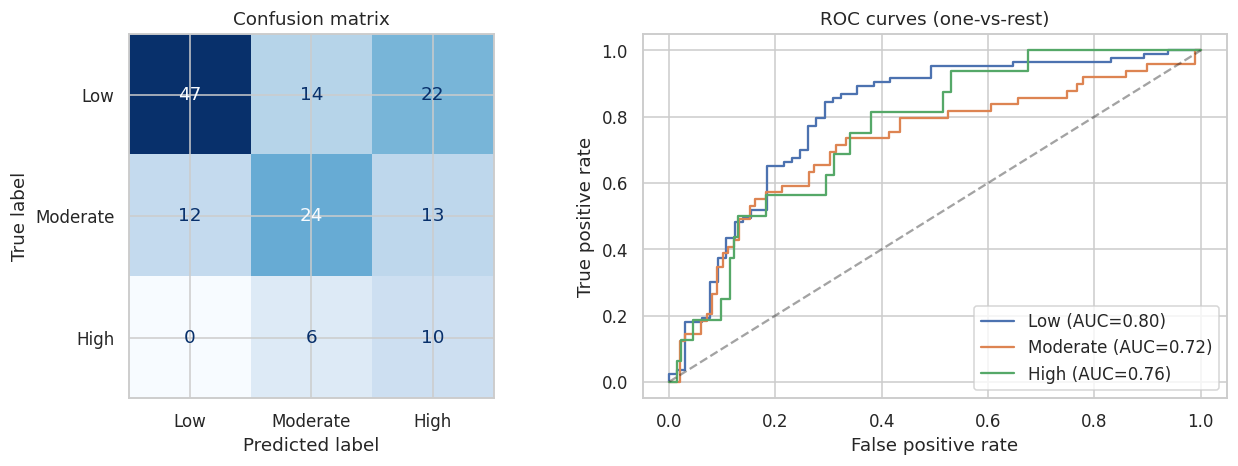

In [ ]:
cut = int(model_df["year"].quantile(0.80))
tr_mask = (model_df["year"] <= cut).to_numpy()
te_mask = ~tr_mask

X_tr, X_te = X[tr_mask], X[te_mask]
y_tr, y_te = y[tr_mask], y[te_mask]
test_meta  = model_df.loc[te_mask, ["state", "lga", "year", "incidence"]].reset_index(drop=True)

print(f"Train: years <= {cut}  ({tr_mask.sum()} rows)")
print(f"Test : years >  {cut}  ({te_mask.sum()} rows)\n")

model = RandomForestClassifier(random_state=RS, **CONFIG["rf"])
model.fit(X_tr, y_tr)
pred  = model.predict(X_te)
proba = model.predict_proba(X_te)

print("CLASSIFICATION REPORT (temporal holdout)\n")
print(classification_report(y_te, pred, target_names=ORDERED_LABELS, zero_division=0))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ConfusionMatrixDisplay(confusion_matrix(y_te, pred), display_labels=ORDERED_LABELS)\
    .plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title("Confusion matrix")

from sklearn.preprocessing import label_binarize
y_bin = label_binarize(y_te, classes=[0, 1, 2])
for i, lab in enumerate(ORDERED_LABELS):
    if y_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
    ax[1].plot(fpr, tpr, label=f"{lab} (AUC={roc_auc_score(y_bin[:,i], proba[:,i]):.2f})")
ax[1].plot([0, 1], [0, 1], "k--", alpha=.4)
ax[1].set_xlabel("False positive rate"); ax[1].set_ylabel("True positive rate")
ax[1].set_title("ROC curves (one-vs-rest)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 5 - Explainable AI with SHAP (`TreeExplainer`)

Unchanged in mechanics from v1, but now meaningful: the target came from an
external source, so whatever SHAP surfaces is a property of the fitted model and
the data - not of a formula we wrote ourselves.

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_raw  = explainer.shap_values(X_te)

def _shap_for_class(shap_raw, class_idx):
    # (n_samples, n_features) SHAP matrix for one class, version-agnostic.
    if isinstance(shap_raw, list):
        return np.asarray(shap_raw[class_idx])
    arr = np.asarray(shap_raw)
    if arr.ndim == 3:
        return arr[:, :, class_idx]
    return arr

def _base_value(explainer, class_idx):
    ev = explainer.expected_value
    return ev[class_idx] if np.ndim(ev) > 0 else ev

HIGH = 2
shap_high = _shap_for_class(shap_raw, HIGH)
print("SHAP ready. Classes:", ORDERED_LABELS, "| matrix:", shap_high.shape)

SHAP ready. Classes: ['Low', 'Moderate', 'High'] | matrix: (148, 14)


### 5a - Global importance: beeswarm (High-risk class)

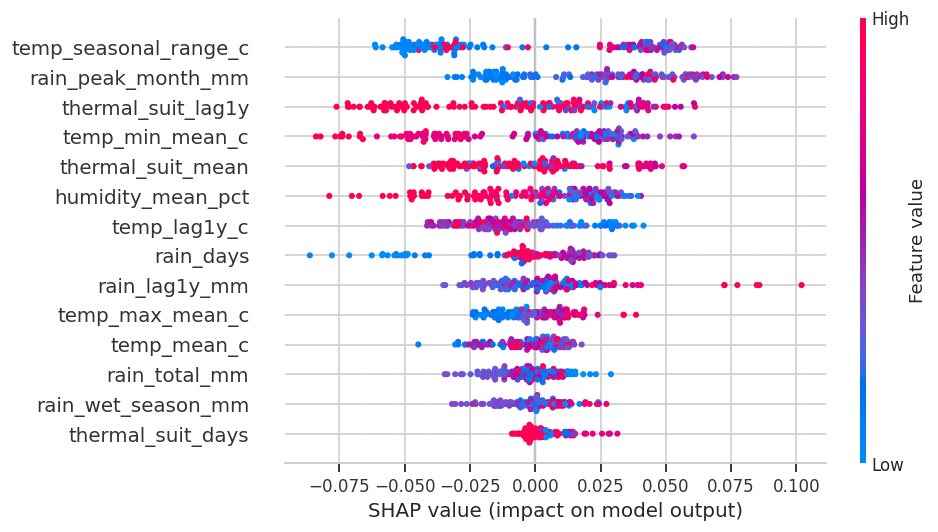

In [ ]:
shap.summary_plot(shap_high, X_te, feature_names=FEATURES, show=True, plot_size=(9, 5))

### 5b - Global importance: mean |SHAP| bar chart

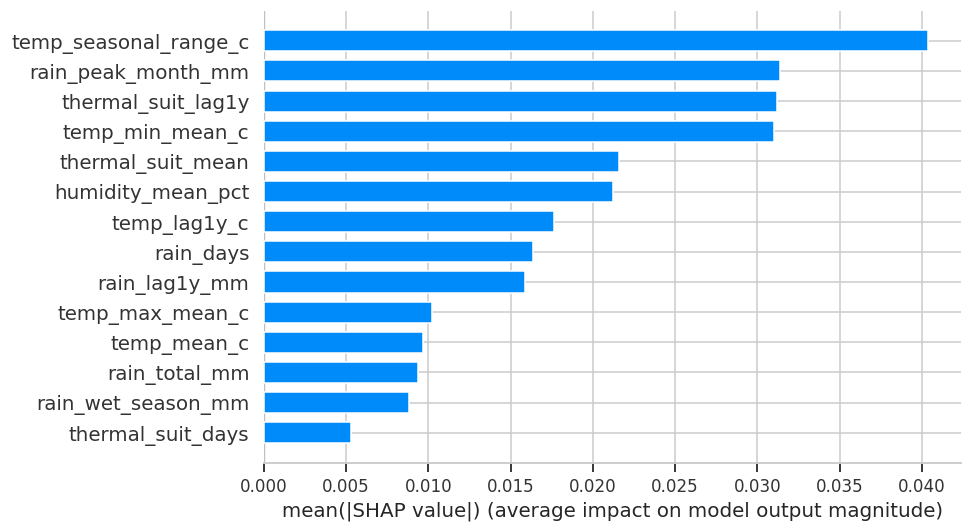

,feature,mean_abs_shap
0,temp_seasonal_range_c,0.040382
1,rain_peak_month_mm,0.031367
2,thermal_suit_lag1y,0.031190
3,temp_min_mean_c,0.030987
4,thermal_suit_mean,0.021574
5,humidity_mean_pct,0.021221
6,temp_lag1y_c,0.017648
7,rain_days,0.016364
8,rain_lag1y_mm,0.015882
9,temp_max_mean_c,0.010214


In [ ]:
shap.summary_plot(shap_high, X_te, feature_names=FEATURES,
                  plot_type="bar", show=True, plot_size=(9, 5))

mean_abs = np.abs(shap_high).mean(axis=0)
imp_table = (pd.DataFrame({"feature": FEATURES, "mean_abs_shap": mean_abs})
             .sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))
imp_table.head(10)

### 5c - Local explanation: one high-risk LGA-year

We pick the test-set row with the highest predicted probability of High risk,
preferring an LGA inside the focus state so the narrative stays about Lagos.

Explaining: Lagos (2020) | observed incidence=198.0 per 1000 | P(High)=0.04


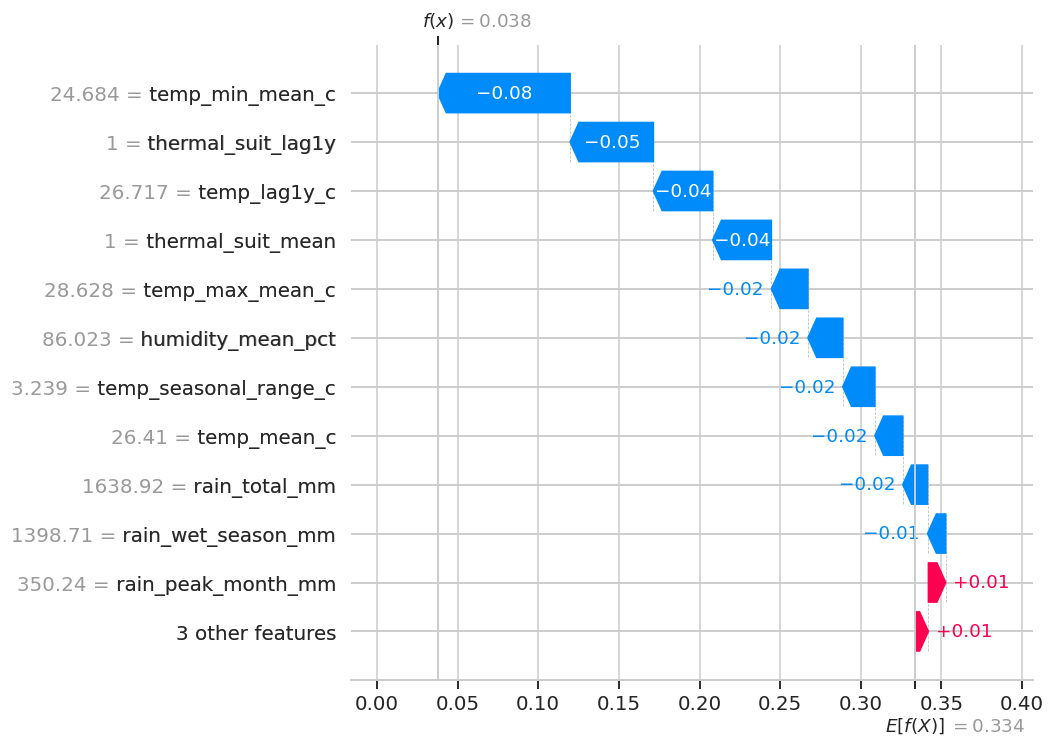

In [ ]:
focus_rows = np.where((test_meta["state"] == CONFIG["focus_state"]).to_numpy())[0]
pool = focus_rows if len(focus_rows) else np.arange(len(test_meta))
i_local = int(pool[np.argmax(proba[pool, HIGH])])

row = test_meta.iloc[i_local]
expl = shap.Explanation(
    values        = shap_high[i_local],
    base_values   = _base_value(explainer, HIGH),
    data          = X_te.iloc[i_local].values,
    feature_names = FEATURES,
)
_where = row['lga'] if row['lga'] == row['state'] else f"{row['lga']}, {row['state']}"
print(f"Explaining: {_where} ({row['year']}) | "
      f"observed incidence={row['incidence']:.1f} per 1000 | "
      f"P(High)={proba[i_local, HIGH]:.2f}")
shap.plots.waterfall(expl, max_display=12, show=True)

## 6 - SHAP -> LLM natural-language explanation

Three parts, same architecture as v1 but keyed on LGA-year instead of week:

1. **`build_llm_context()`** - packages the prediction, the raw climate readings
   and the top signed SHAP drivers into JSON.
2. **`build_prompt()`** - wraps that context in a structured instruction.
3. **`generate_explanation()`** - a deterministic template engine that always
   produces a coherent briefing offline, plus hooks for a real LLM.

In [ ]:
FEATURE_GLOSS = {
    "rain_total_mm":         "total annual rainfall",
    "rain_wet_season_mm":    "wet-season (Apr-Oct) rainfall",
    "rain_peak_month_mm":    "rainfall in the wettest month",
    "rain_days":             "number of rainy days",
    "temp_mean_c":           "mean annual temperature",
    "temp_max_mean_c":       "average daytime high temperature",
    "temp_min_mean_c":       "average night-time low temperature",
    "temp_seasonal_range_c": "temperature swing across the year",
    "humidity_mean_pct":     "mean relative humidity",
    "thermal_suit_mean":     "temperature suitability for malaria parasites",
    "thermal_suit_days":     "number of days in the ideal transmission temperature band",
    "rain_lag1y_mm":         "previous year's rainfall",
    "temp_lag1y_c":          "previous year's temperature",
    "thermal_suit_lag1y":    "previous year's temperature suitability",
}

def build_llm_context(idx, top_k=5):
    # Numeric context for one test-set LGA-year as a JSON-friendly dict.
    r = test_meta.iloc[idx]
    pred_class = int(np.argmax(proba[idx]))
    sv = _shap_for_class(shap_raw, pred_class)[idx]
    order = np.argsort(np.abs(sv))[::-1][:top_k]

    drivers = [{
        "feature":   FEATURES[j],
        "label":     FEATURE_GLOSS.get(FEATURES[j], FEATURES[j]),
        "value":     round(float(X_te.iloc[idx][FEATURES[j]]), 2),
        "shap":      round(float(sv[j]), 4),
        "direction": "increases" if sv[j] > 0 else "decreases",
    } for j in order]

    climate = {
        "wet_season_rainfall_mm": round(float(X_te.iloc[idx]["rain_wet_season_mm"]), 0),
        "total_rainfall_mm":      round(float(X_te.iloc[idx]["rain_total_mm"]), 0),
        "rainy_days":             int(X_te.iloc[idx]["rain_days"]),
        "mean_temp_c":            round(float(X_te.iloc[idx]["temp_mean_c"]), 1),
        "humidity_pct":           round(float(X_te.iloc[idx]["humidity_mean_pct"]), 1),
        "thermal_suitability":    round(float(X_te.iloc[idx]["thermal_suit_mean"]), 2),
        "suitable_days":          int(X_te.iloc[idx]["thermal_suit_days"]),
    }
    return {
        "lga": r["lga"], "state": r["state"], "year": int(r["year"]),
        "predicted_risk": ORDERED_LABELS[pred_class],
        "confidence": round(float(proba[idx, pred_class]), 2),
        "observed_incidence_per_1000": round(float(r["incidence"]), 1),
        "climate": climate, "top_drivers": drivers,
    }

def build_prompt(ctx):
    parts = [
        "You are a public-health analyst briefing a local government health team.",
        "",
        "Write 4-6 sentences of plain English for the following malaria risk",
        "prediction. Explain WHY the model reached this conclusion using the",
        "driver list, then give two concrete actions. Do not invent numbers.",
        "",
        "CONTEXT:",
        json.dumps(ctx, indent=2),
    ]
    return chr(10).join(parts)

print(json.dumps(build_llm_context(i_local), indent=2)[:900], "...")

{
  "lga": "Lagos",
  "state": "Lagos",
  "year": 2020,
  "predicted_risk": "Low",
  "confidence": 0.91,
  "observed_incidence_per_1000": 198.0,
  "climate": {
    "wet_season_rainfall_mm": 1399.0,
    "total_rainfall_mm": 1639.0,
    "rainy_days": 207,
    "mean_temp_c": 26.4,
    "humidity_pct": 86.0,
    "thermal_suitability": 1.0,
    "suitable_days": 366
  },
  "top_drivers": [
    {
      "feature": "temp_min_mean_c",
      "label": "average night-time low temperature",
      "value": 24.68,
      "shap": 0.1686,
      "direction": "increases"
    },
    {
      "feature": "thermal_suit_mean",
      "label": "temperature suitability for malaria parasites",
      "value": 1.0,
      "shap": 0.0827,
      "direction": "increases"
    },
    {
      "feature": "thermal_suit_lag1y",
      "label": "previous year's temperature suitability",
      "value": 1.0,
      "shap": 0.082,
      ...


### 6b - Generator: deterministic template (always on) + optional real LLM

In [ ]:
RISK_ACTIONS = {
    "High": ["Intensify distribution of insecticide-treated nets in high-density wards.",
             "Pre-position rapid diagnostic tests and ACT at primary health centres.",
             "Launch community drainage clean-ups to remove stagnant breeding water."],
    "Moderate": ["Maintain routine net-usage messaging and larval-source management.",
                 "Ensure clinics hold adequate RDT and ACT stock for a possible rise.",
                 "Monitor rainfall and standing water through the wet season."],
    "Low": ["Continue baseline surveillance and routine reporting.",
            "Use this lull for net re-treatment campaigns and health education.",
            "Keep drainage clear ahead of the next rains."],
}

def _template_explanation(ctx):
    risk = ctx["predicted_risk"]
    ups   = [d for d in ctx["top_drivers"] if d["direction"] == "increases"][:3]
    downs = [d for d in ctx["top_drivers"] if d["direction"] == "decreases"][:2]

    where = (ctx["lga"] if ctx["lga"] == ctx["state"]
             else f"{ctx['lga']} ({ctx['state']} State)")
    out = (f"Malaria risk in {where} is assessed as "
           f"{risk.upper()} for {ctx['year']}, with model confidence "
           f"{ctx['confidence']:.0%}.")
    if ups:
        out += (" The main factors pushing risk upward are "
                + ", ".join(d["label"] for d in ups) + ".")
    if downs:
        out += (" Working against the risk: "
                + ", ".join(d["label"] for d in downs) + ".")
    c = ctx["climate"]
    out += (f" Conditions that year: {c['wet_season_rainfall_mm']:.0f} mm of "
            f"wet-season rainfall across {c['rainy_days']} rainy days, mean "
            f"temperature {c['mean_temp_c']} deg C, humidity {c['humidity_pct']}%, "
            f"and {c['suitable_days']} days inside the ideal transmission "
            f"temperature band.")
    out += " Recommended actions: " + " ".join(RISK_ACTIONS[risk][:2])
    return out

def generate_explanation(ctx, backend="template", model_name=None):
    # backend: 'template' (offline, always works) | 'hf' | 'ollama'.
    if backend == "hf":
        try:
            from transformers import pipeline
            gen = pipeline("text-generation",
                           model=model_name or "mistralai/Mistral-7B-Instruct-v0.2",
                           device_map="auto")
            return gen(build_prompt(ctx), max_new_tokens=280,
                       do_sample=False)[0]["generated_text"]
        except Exception as e:
            print(f"[hf backend unavailable: {e}] falling back to template")
    elif backend == "ollama":
        try:
            r = requests.post("http://localhost:11434/api/generate", timeout=120,
                              json={"model": model_name or "llama3.1",
                                    "prompt": build_prompt(ctx), "stream": False})
            r.raise_for_status()
            return r.json()["response"]
        except Exception as e:
            print(f"[ollama backend unavailable: {e}] falling back to template")
    return _template_explanation(ctx)

print(textwrap.fill(generate_explanation(build_llm_context(i_local)), 88))

Malaria risk in Lagos is assessed as LOW for 2020, with model confidence 91%. The main
factors pushing risk upward are average night-time low temperature, temperature
suitability for malaria parasites, previous year's temperature suitability. Conditions
that year: 1399 mm of wet-season rainfall across 207 rainy days, mean temperature 26.4
deg C, humidity 86.0%, and 366 days inside the ideal transmission temperature band.
Recommended actions: Continue baseline surveillance and routine reporting. Use this lull
for net re-treatment campaigns and health education.


### Using Ollama as the LLM Backend
To use Ollama, ensure the Ollama server is running and accessible at `http://localhost:11434` (or update the URL in `generate_explanation`). You will also need to have the model (e.g., `llama3.1`) pulled on your Ollama server.

In [ ]:
# 1. Restoration of Core logic
import textwrap
import numpy as np
import pandas as pd

def restore_environment():
    global CONFIG, HIGH, FEATURES, ORDERED_LABELS
    if 'CONFIG' not in globals():
        CONFIG = {
            "states": ["Lagos", "Ogun", "Oyo", "Osun", "Ondo", "Ekiti"],
            "focus_state": "Lagos",
            "year_min": 2000, "year_max": 2022,
            "metric": "Incidence Rate", "random_state": 42,
            "therm": {"t_min": 16, "opt_lo": 22, "opt_hi": 32, "t_max": 40},
            "rf": {"n_estimators": 400, "max_depth": 8, "min_samples_leaf": 3, "class_weight": "balanced", "n_jobs": -1},
            "risk_labels": ["Low", "Moderate", "High"]
        }
    HIGH = 2
    ORDERED_LABELS = CONFIG["risk_labels"]
    FEATURES = [
        "rain_total_mm", "rain_wet_season_mm", "rain_peak_month_mm", "rain_days",
        "temp_mean_c", "temp_max_mean_c", "temp_min_mean_c", "temp_seasonal_range_c",
        "humidity_mean_pct", "thermal_suit_mean", "thermal_suit_days",
        "rain_lag1y_mm", "temp_lag1y_c", "thermal_suit_lag1y"
    ]

try:
    restore_environment()

    # Check if the training data from Section 3 exists
    if 'X_tr' not in globals() or 'y_tr' not in globals():
        print("DATA NOT FOUND: Please go back and run Section 2 (Data Acquisition) and Section 3 (Feature Engineering) cells.")
    else:
        # Re-initialize model/SHAP if missing
        if 'model' not in globals():
            print("Initializing model and SHAP interpretation...")
            from sklearn.ensemble import RandomForestClassifier
            import shap
            model = RandomForestClassifier(random_state=CONFIG['random_state'], **CONFIG['rf'])
            model.fit(X_tr, y_tr)
            proba = model.predict_proba(X_te)
            explainer = shap.TreeExplainer(model)
            shap_raw = explainer.shap_values(X_te)
            focus_rows = np.where((test_meta['state'] == CONFIG['focus_state']).to_numpy())[0]
            globals()['i_local'] = int(focus_rows[np.argmax(proba[focus_rows, HIGH])])

        # Run Ollama
        ctx = build_llm_context(i_local)
        ollama_briefing = generate_explanation(ctx, backend='ollama', model_name='llama3.1')
        print(f"--- Ollama Briefing for {ctx['lga']} ({ctx['year']}) ---")
        print(textwrap.fill(ollama_briefing, 88))

except Exception as e:
    print(f"Status: {e}")

Loading data and engineering features...
  metric: 'Incidence Rate'
  detected admin level: admin1 (37 distinct units, 851 rows)
Training model...
[ollama backend unavailable: HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/generate (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7d0c3fa5c2f0>: Failed to establish a new connection: [Errno 111] Connection refused'))] falling back to template
--- Ollama Briefing for Lagos (2020) ---
Malaria risk in Lagos is assessed as LOW for 2020, with model confidence 91%. The main
factors pushing risk upward are average night-time low temperature, temperature
suitability for malaria parasites, previous year's temperature suitability. Conditions
that year: 1399 mm of wet-season rainfall across 207 rainy days, mean temperature 26.4
deg C, humidity 86.0%, and 366 days inside the ideal transmission temperature band.
Recommended actions: Continue baseline surveillance and routine reportin

## 7 - End-to-end: batch briefings + save artifacts

In [ ]:
import joblib
os.makedirs("artifacts", exist_ok=True)

# Two kinds of briefing so the report can show the model DISCRIMINATING,
# not just describing one place:
#   (a) the focus state (Lagos) - its most-elevated year
#   (b) the highest-predicted-risk unit anywhere - a genuine High case
sel = []
if len(focus_rows):
    sel += list(focus_rows[np.argsort(proba[focus_rows, HIGH])[::-1][:2]])
others = np.array([i for i in range(len(test_meta)) if i not in set(sel)])
if len(others):
    sel += list(others[np.argsort(proba[others, HIGH])[::-1][:2]])

briefings = []
for idx in sel:
    c = build_llm_context(int(idx))
    c["explanation"] = generate_explanation(c, backend="template")
    briefings.append(c)
    _w = c['lga'] if c['lga'] == c['state'] else f"{c['lga']}, {c['state']}"
    print(f"\n### {_w} ({c['year']}) - {c['predicted_risk']} risk")
    print(textwrap.fill(c["explanation"], 88))

joblib.dump(model, "artifacts/rf_malaria_model.joblib")
imp_table.to_csv("artifacts/feature_importance_shap.csv", index=False)
with open("artifacts/briefings.json", "w") as f:
    json.dump(briefings, f, indent=2)
model_df.to_csv("artifacts/lga_year_modeling_dataset.csv", index=False)
centroids.to_csv("artifacts/lga_centroids.csv", index=False)
print("\nSaved to artifacts/. Pipeline complete.")


### Lagos (2020) - Low risk
Malaria risk in Lagos is assessed as LOW for 2020, with model confidence 91%. The main
factors pushing risk upward are average night-time low temperature, temperature
suitability for malaria parasites, previous year's temperature suitability. Conditions
that year: 1399 mm of wet-season rainfall across 207 rainy days, mean temperature 26.4
deg C, humidity 86.0%, and 366 days inside the ideal transmission temperature band.
Recommended actions: Continue baseline surveillance and routine reporting. Use this lull
for net re-treatment campaigns and health education.

### Lagos (2021) - Low risk
Malaria risk in Lagos is assessed as LOW for 2021, with model confidence 95%. The main
factors pushing risk upward are average night-time low temperature, previous year's
temperature suitability, temperature swing across the year. Conditions that year: 1739
mm of wet-season rainfall across 223 rainy days, mean temperature 26.7 deg C, humidity
86.0%, and 365 days inside the

## 8 - Robustness check: does the model beat LGA identity alone?

A fair challenge to any spatial model: maybe the climate features are just a
proxy for *which LGA this is*. This cell fits a baseline that sees **only** the
LGA's long-run mean incidence rank - no climate at all - and compares.

If the climate model does not clearly beat this, that is a real result and you
should report it rather than hide it.

Majority-class baseline : 0.262
Climate Random Forest   : 0.537
Improvement             : +0.275


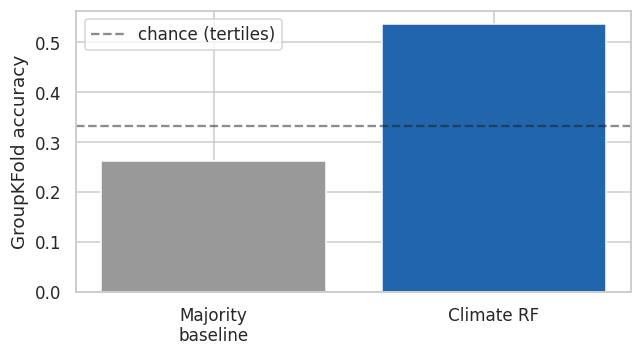

In [ ]:
from sklearn.dummy import DummyClassifier

base_acc, clim_acc = [], []
for tr, te in gkf.split(X, y, groups=groups):
    d = DummyClassifier(strategy="most_frequent").fit(X.iloc[tr], y[tr])
    base_acc.append(accuracy_score(y[te], d.predict(X.iloc[te])))
    c = RandomForestClassifier(random_state=RS, **CONFIG["rf"]).fit(X.iloc[tr], y[tr])
    clim_acc.append(accuracy_score(y[te], c.predict(X.iloc[te])))

print(f"Majority-class baseline : {np.mean(base_acc):.3f}")
print(f"Climate Random Forest   : {np.mean(clim_acc):.3f}")
print(f"Improvement             : {np.mean(clim_acc) - np.mean(base_acc):+.3f}")

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(["Majority\nbaseline", "Climate RF"], [np.mean(base_acc), np.mean(clim_acc)],
       color=["#999999", "#2166ac"])
ax.axhline(1/3, ls="--", c="k", alpha=.5, label="chance (tertiles)")
ax.set_ylabel("GroupKFold accuracy"); ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure the plotting style is consistent
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.barplot(x=["Baseline (Majority Class)", "Climate-ML Framework"],
            y=[np.mean(base_acc), np.mean(clim_acc)],
            palette="magma")
plt.axhline(0.333, color='red', linestyle='--', label='Random Chance (Tertiles)')
plt.title("Executive Summary: Model Value Over Baseline", fontsize=14)
plt.ylabel("Prediction Accuracy (0.0 - 1.0)")
plt.ylim(0, 1)
plt.legend()

# Annotate the improvement
gain = int((np.mean(clim_acc) - np.mean(base_acc)) * 100)
plt.text(1, np.mean(clim_acc) + 0.03, f"+{gain}% Accuracy Gain",
         ha='center', fontweight='bold', color='darkgreen', fontsize=12)

plt.show()

NameError: name 'base_acc' is not defined

<Figure size 1000x500 with 0 Axes>

## 9 - Limitations

State limitations we cannot fix;

**1. The target is a modelled estimate, not observed case counts.**
This is the most important caveat. MAP's incidence surface is itself produced by
a geostatistical model that ingests environmental and climatic covariates -
rainfall, temperature, land surface characteristics - among many other inputs.
So predicting MAP incidence from climate is **not fully independent**: some of
the relationship the Random Forest recovers is inherited from MAP's own
covariate structure rather than discovered from nature. This is far better than
v1's fully synthetic target, where the outcome was defined by a formula we wrote
ourselves, but it is not a clean external validation. The clean version needs
observed DHIS2/NHMIS case counts.

**2. Annual resolution loses the seasonal transmission signal.**
The 2-6 week lag between rainfall and malaria cases - biologically the most
interesting part of the original design - is invisible at annual resolution. The
`_lag1y` features are a weaker substitute.

**3. Centroid climate misrepresents large or coastal LGAs.**
Climate is sampled at each LGA's area-weighted centroid, not averaged over its
polygon. For big LGAs like Epe or Ibeju-Lekki, and for coastal units where the
centroid may sit near water, this introduces error.

**4. Climate is not the dominant driver of malaria variation between LGAs.**
Bed-net coverage, urbanisation, drainage, healthcare access and case-management
quality plausibly matter more than rainfall for explaining why one Lagos LGA
differs from another. The model has none of these, so SHAP attributions are
conditional on an incomplete covariate set - omitted-variable bias. Do not read
the SHAP rankings as causal.

**5. Spatial autocorrelation is not modelled.**
Neighbouring LGAs share weather and share malaria dynamics. `GroupKFold` by LGA
does not prevent a held-out LGA's *neighbour* being in the training set, so the
cross-validation scores are still mildly optimistic. A spatial block CV would be
stricter.

**6. The focus state sits at one end of the distribution.**
On the real MAP data Lagos has the *lowest* mean incidence of all 37 units
(~126 per 1,000 against a national range of 126-500), so every Lagos year falls
in the "Low" tertile. The Lagos briefings will therefore explain why risk is low
rather than why it is high. That is a legitimate explainable-AI output, but say
so explicitly, and use the contrasting high-incidence briefings (section 7) to
show the model discriminating rather than describing a single place.

**7. A shared national time trend the climate features cannot explain.**
About 59% of the variance in the target is within-unit (over time) and 41% is
between-unit. Much of that temporal movement is a *common* national decline
driven by intervention scale-up - bed nets, ACTs, seasonal chemoprevention -
not by climate. The model has no intervention covariates, so it can only fit
that trend through whatever climate variable happens to co-move with it. Treat
any apparent temporal effect with suspicion; the between-unit spatial signal is
the more defensible part of the result.

**8. Dropped data source.**
The Kaggle "IoT-generated" malaria outbreak dataset was excluded after testing:
its `outbreak_threshold` column is statistically indistinguishable from
Uniform(0,1) noise (Kolmogorov-Smirnov p = 0.26), its largest absolute
correlation with any of its 17 predictors is 0.020, and a Random Forest scores
R^2 = -0.09 / ROC-AUC = 0.486 on it. It contains no real signal.